    # Portfolio Optimization using Machine Learning

This notebook walks through the full portfolio optimization pipeline:
1. **Data Collection** — Download stock prices from Yahoo Finance
2. **Feature Engineering** — Compute returns, covariance matrices, and ML features
3. **Optimization** — Markowitz Mean-Variance with different risk estimators
4. **Backtesting** — Test on out-of-sample data with transaction costs
5. **Analysis** — Compare strategies and explain results honestly

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path so we can import our modules
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import download_data, split_data
from src.feature_engineering import (
    compute_returns, compute_expected_returns,
    compute_covariance_raw, compute_covariance_shrinkage,
    train_volatility_model, predict_covariance_ml,
    compute_rolling_volatility
)
from src.optimization import (
    optimize_max_sharpe, equal_weight_portfolio,
    random_weight_portfolio, compute_efficient_frontier
)
from src.evaluation import (
    backtest_portfolio, compute_sharpe_ratio, compute_max_drawdown,
    compute_cumulative_returns, compare_portfolios
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Collection

We use 18 stocks diversified across 6 sectors to build a realistic portfolio. Using stocks from only one sector (e.g., all tech) would defeat the purpose of diversification.

In [2]:
TICKERS = [
    # Technology
    "AAPL", "MSFT", "GOOGL", "NVDA",
    # Healthcare
    "JNJ", "UNH", "PFE",
    # Finance
    "JPM", "V", "BAC",
    # Consumer
    "AMZN", "PG", "KO",
    # Energy
    "XOM", "CVX",
    # Industrials
    "CAT", "HON",
    # High-volatility
    "TSLA",
]

prices = download_data(TICKERS, start="2019-01-01", end="2024-01-01")
print(f"\nShape: {prices.shape}")
prices.head()

[                       0%                       ]

[*****                 11%                       ]  2 of 18 completed

[***********           22%                       ]  4 of 18 completed

[*************         28%                       ]  5 of 18 completed

[****************      33%                       ]  6 of 18 completed

...

[**********************89%******************     ]  16 of 18 completed

[**********************94%********************   ]  17 of 18 completed

[*********************100%***********************]  18 of 18 completed

Downloaded 1258 trading days of data.

Shape: (1258, 18)


Ticker,AAPL,AMZN,BAC,CAT,CVX,GOOGL,HON,JNJ,JPM,KO,MSFT,NVDA,PFE,PG,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,
2019-01-02,37.503735,76.956497,20.945078,108.229248,80.604248,52.301727,106.928429,104.387901,80.836479,37.582684,94.397148,3.376983,29.294348,75.915634,20.674667,215.453140,126.329430,50.001850
2019-01-03,33.768070,75.014000,20.609423,104.058693,79.060455,50.853199,105.500847,102.729111,79.687668,37.350445,90.924492,3.172956,28.474787,75.383354,20.024000,209.577713,121.776962,49.234138
2019-01-04,35.209618,78.769501,21.465353,109.745049,80.698906,53.461639,109.191422,104.453270,82.625412,38.095230,95.153282,3.376240,29.125031,76.921944,21.179333,212.028793,127.023232,51.049374
2019-01-07,35.131237,81.475502,21.448566,109.813553,81.747536,53.355022,109.799759,103.783211,82.682816,37.598705,95.274658,3.554981,29.280809,76.614258,22.330667,212.435822,129.313736,51.314846
2019-01-08,35.800949,82.829002,21.406612,111.132393,81.390701,53.823650,109.572624,106.193741,82.526924,38.023148,95.965454,3.466478,29.416275,76.897018,22.356667,215.276169,130.017059,51.687943


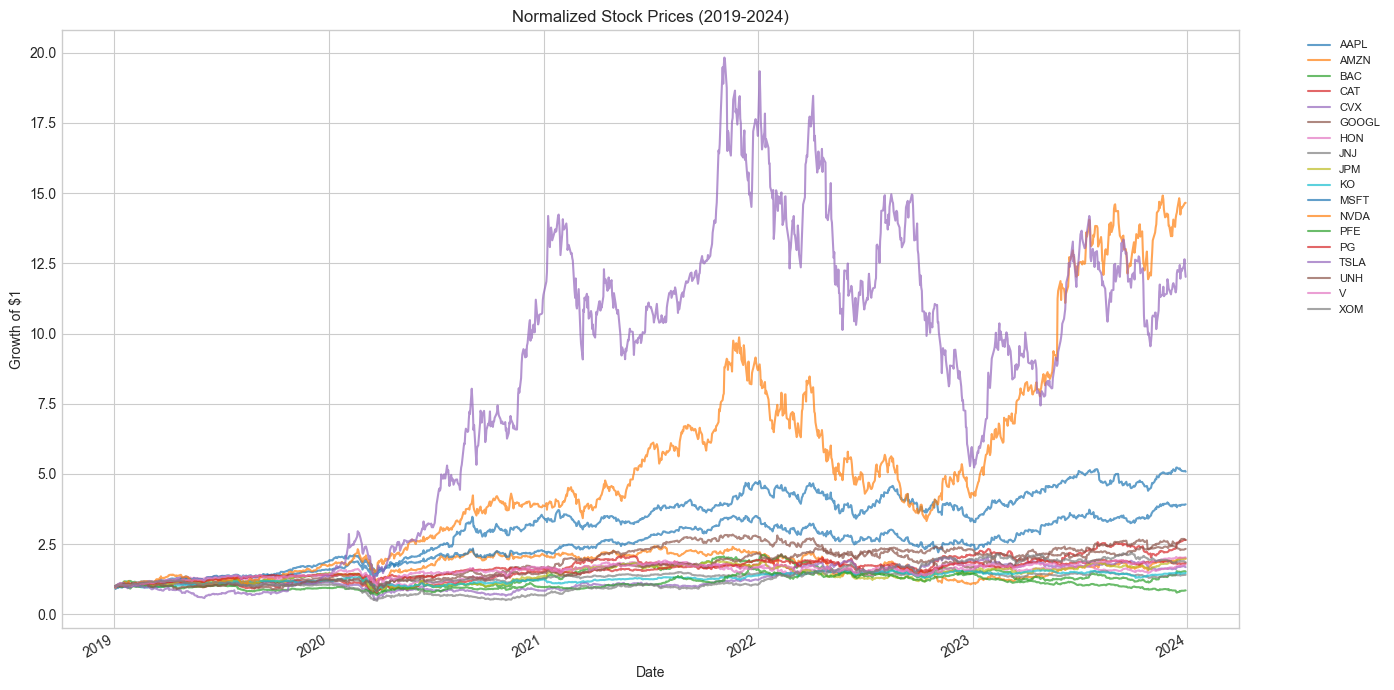

In [3]:
# Normalize prices to $1 starting point to compare growth
normalized = prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))
normalized.plot(ax=ax, alpha=0.7)
ax.set_title("Normalized Stock Prices (2019-2024)")
ax.set_ylabel("Growth of $1")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Train/Test Split

**Critical:** We split chronologically, NOT randomly. Random splits in time-series data cause look-ahead bias — the model would "see" future prices during training, making results unrealistically good.

- **Training:** 2019-01-01 to 2022-12-31 (learn patterns)
- **Testing:** 2023-01-01 to 2023-12-31 (evaluate on unseen data)

In [4]:
prices_train, prices_test = split_data(prices, train_end="2022-12-31")

returns_train = compute_returns(prices_train)
returns_test = compute_returns(prices_test)

print(f"\nTraining returns shape: {returns_train.shape}")
print(f"Test returns shape: {returns_test.shape}")

Train set: 2019-01-02 to 2022-12-30 (1008 days)
Test set:  2023-01-04 to 2023-12-29 (249 days)

Training returns shape: (1007, 18)
Test returns shape: (248, 18)


## 3. Feature Engineering

### 3.1 Expected Returns and Risk

We compute expected returns and three different covariance matrices:
1. **Raw covariance** — Simple sample covariance (baseline)
2. **Ledoit-Wolf shrinkage** — Regularized covariance that reduces estimation error
3. **ML-adjusted** — Shrinkage covariance scaled by Random Forest volatility predictions

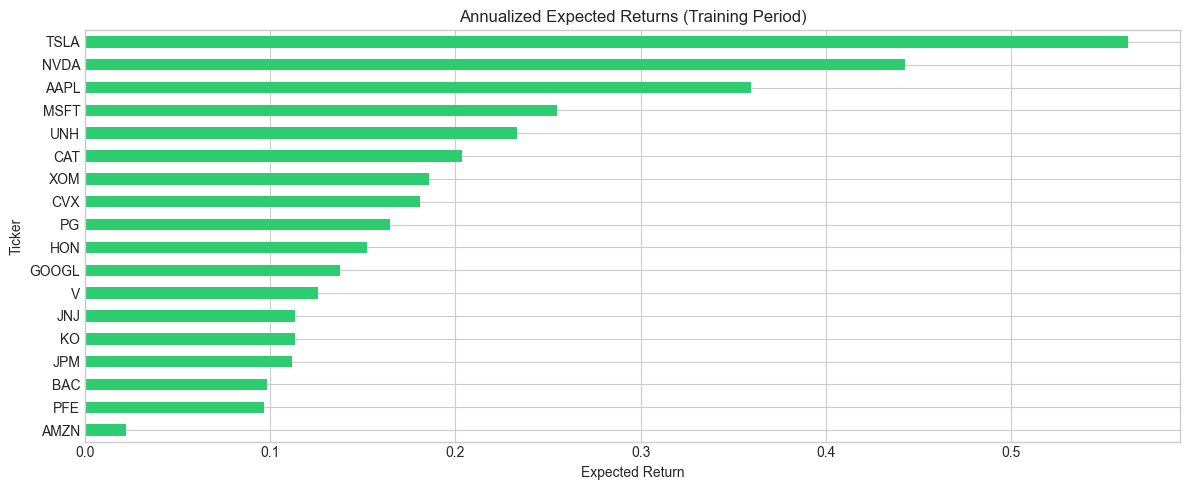

In [5]:
mu = compute_expected_returns(prices_train)

# Display as a sorted bar chart
fig, ax = plt.subplots(figsize=(12, 5))
mu_sorted = mu.sort_values(ascending=True)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in mu_sorted]
mu_sorted.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Annualized Expected Returns (Training Period)")
ax.set_xlabel("Expected Return")
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

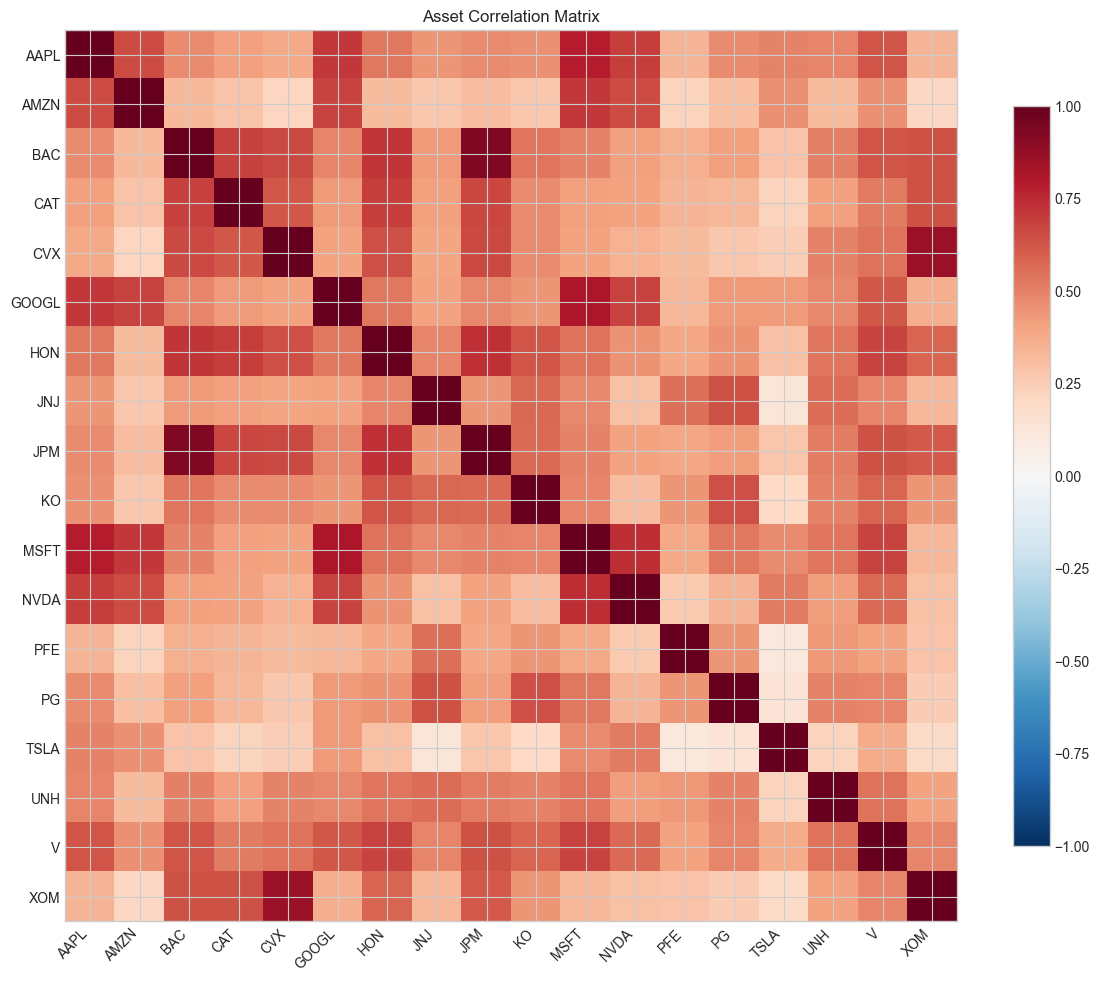

Note: High correlation between tech stocks (AAPL, MSFT, GOOGL, NVDA).
Low correlation between tech and energy/consumer staples — this is why diversification helps.


In [6]:
# Correlation heatmap to understand asset relationships
import matplotlib.colors as mcolors

corr = returns_train.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Asset Correlation Matrix")
plt.tight_layout()
plt.show()

print("Note: High correlation between tech stocks (AAPL, MSFT, GOOGL, NVDA).")
print("Low correlation between tech and energy/consumer staples — this is why diversification helps.")

In [7]:
cov_raw = compute_covariance_raw(returns_train)
cov_shrink = compute_covariance_shrinkage(prices_train)

# Compare the two: shrinkage pulls extreme values toward the diagonal
diff = cov_raw - cov_shrink
print("Difference between raw and shrinkage covariance (abs mean per asset):")
print(diff.abs().mean().sort_values(ascending=False).head(5))
print("\nShrinkage has the most effect on high-volatility assets like TSLA and NVDA.")

Difference between raw and shrinkage covariance (abs mean per asset):
Ticker
NVDA    0.001875
TSLA    0.001804
BAC     0.001388
AAPL    0.001278
MSFT    0.001265
dtype: float64

Shrinkage has the most effect on high-volatility assets like TSLA and NVDA.


### 3.2 ML Volatility Prediction

We train a Random Forest regressor per stock to predict forward-looking 21-day volatility. This uses features that are purely backward-looking (rolling returns and volatility), so there's no data leakage.

The predicted volatility is used to adjust the covariance matrix — if the model predicts a stock will be more volatile than its historical average, we scale up its covariance entries.

In [8]:
print("Training Random Forest volatility models...\n")
vol_models = train_volatility_model(returns_train)

Training Random Forest volatility models...



  Trained volatility model for AAPL (R² = 0.963)
  Trained volatility model for AMZN (R² = 0.960)


  Trained volatility model for BAC (R² = 0.969)
  Trained volatility model for CAT (R² = 0.971)


  Trained volatility model for CVX (R² = 0.968)


  Trained volatility model for GOOGL (R² = 0.951)
  Trained volatility model for HON (R² = 0.953)


...

  Trained volatility model for NVDA (R² = 0.963)


  Trained volatility model for PFE (R² = 0.944)
  Trained volatility model for PG (R² = 0.959)


  Trained volatility model for TSLA (R² = 0.957)
  Trained volatility model for UNH (R² = 0.981)


  Trained volatility model for V (R² = 0.966)


  Trained volatility model for XOM (R² = 0.978)


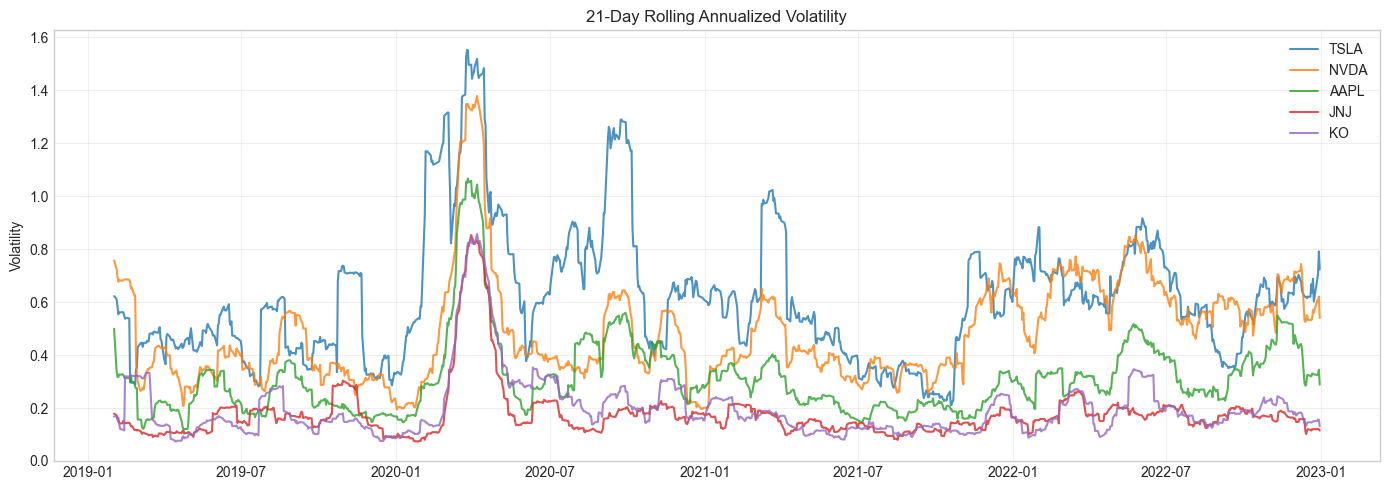

TSLA and NVDA are significantly more volatile than defensive stocks like JNJ and KO.
The ML model learns these volatility patterns to make better forward predictions.


In [9]:
# Visualize rolling volatility for a few stocks
vol_21 = compute_rolling_volatility(returns_train, window=21) * np.sqrt(252)  # annualize

fig, ax = plt.subplots(figsize=(14, 5))
for ticker in ["TSLA", "NVDA", "AAPL", "JNJ", "KO"]:
    ax.plot(vol_21.index, vol_21[ticker], label=ticker, alpha=0.8)
ax.set_title("21-Day Rolling Annualized Volatility")
ax.set_ylabel("Volatility")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("TSLA and NVDA are significantly more volatile than defensive stocks like JNJ and KO.")
print("The ML model learns these volatility patterns to make better forward predictions.")

In [10]:
cov_ml = predict_covariance_ml(vol_models, returns_train, prices_train)

  ML-adjusted covariance matrix computed.


## 4. Portfolio Optimization

We use Markowitz Mean-Variance Optimization to find weights that maximize the Sharpe ratio (return per unit of risk). We run this with each of the three covariance matrices, plus two baselines.

In [11]:
print("=== Max Sharpe (Raw Covariance) ===")
w_raw, perf_raw = optimize_max_sharpe(mu, cov_raw)

print("\n=== Max Sharpe (Shrinkage Covariance) ===")
w_shrink, perf_shrink = optimize_max_sharpe(mu, cov_shrink)

print("\n=== Max Sharpe (ML-Adjusted Covariance) ===")
w_ml, perf_ml = optimize_max_sharpe(mu, cov_ml)

w_equal = equal_weight_portfolio(TICKERS)
w_random = random_weight_portfolio(TICKERS)

=== Max Sharpe (Raw Covariance) ===
  Expected Return: 30.57%
  Volatility:      26.11%
  Sharpe Ratio:    1.17

=== Max Sharpe (Shrinkage Covariance) ===
  Expected Return: 30.74%
  Volatility:      26.09%
  Sharpe Ratio:    1.18

=== Max Sharpe (ML-Adjusted Covariance) ===
  Expected Return: 21.25%
  Volatility:      13.11%
  Sharpe Ratio:    1.62


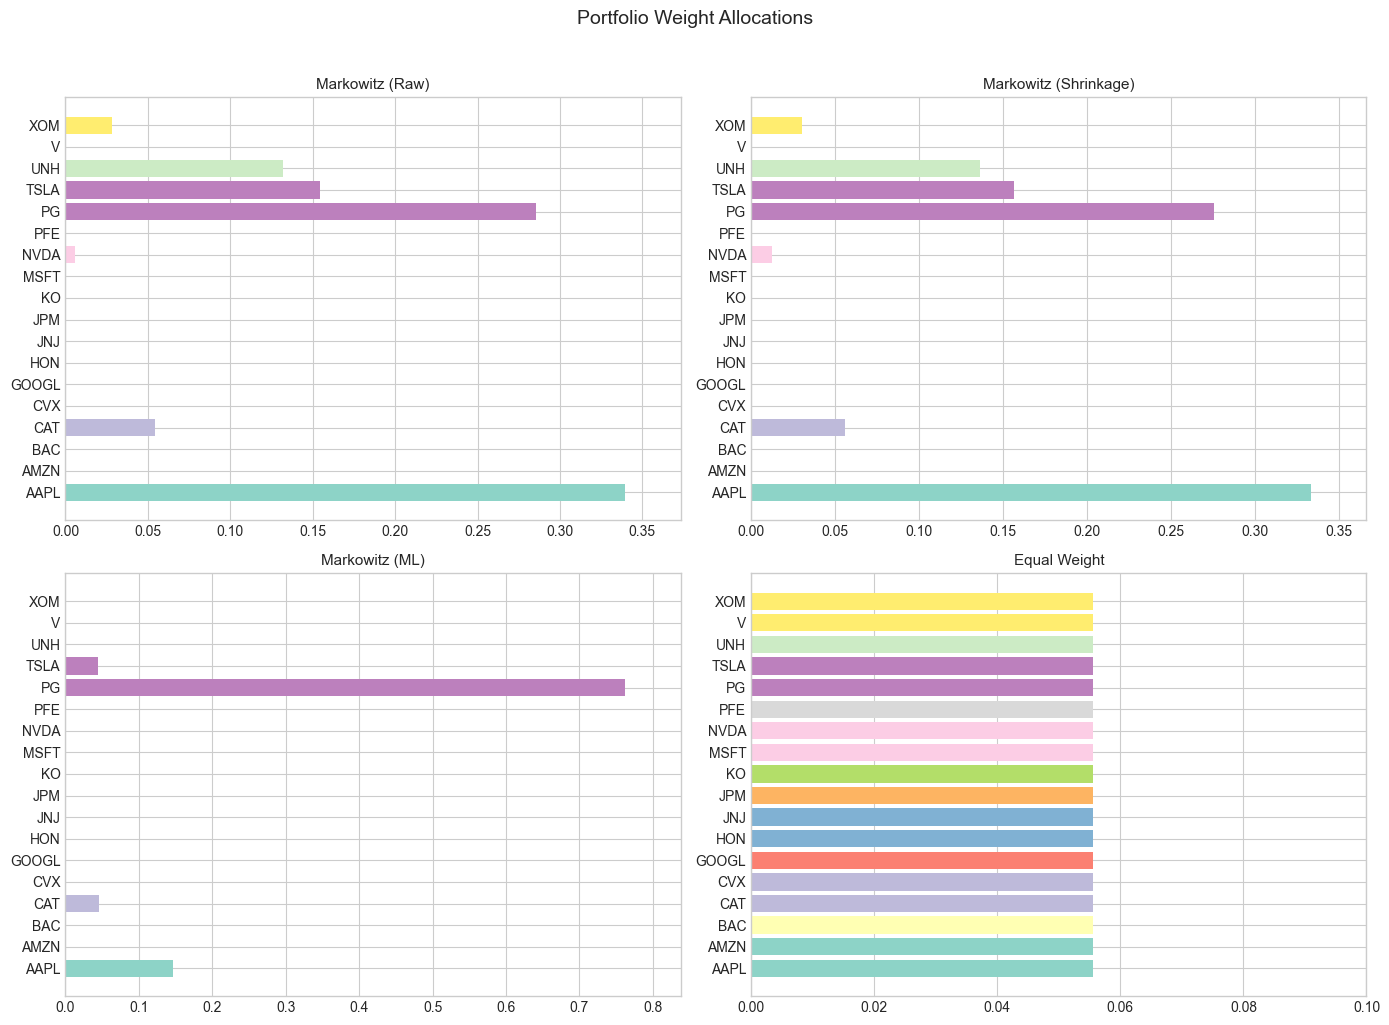

Markowitz (Raw): 6 active positions out of 18
Markowitz (Shrinkage): 7 active positions out of 18
Markowitz (ML): 4 active positions out of 18
Equal Weight: 18 active positions out of 18


In [12]:
# Visualize the weight allocations
all_weights = {
    "Markowitz (Raw)": w_raw,
    "Markowitz (Shrinkage)": w_shrink,
    "Markowitz (ML)": w_ml,
    "Equal Weight": w_equal,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, weights) in zip(axes, all_weights.items()):
    tickers_sorted = sorted(weights.keys())
    vals = [weights[t] for t in tickers_sorted]
    colors = plt.cm.Set3(np.linspace(0, 1, len(tickers_sorted)))
    ax.barh(tickers_sorted, vals, color=colors)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(0, max(max(vals) * 1.1, 0.1))

plt.suptitle("Portfolio Weight Allocations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Count active positions
for name, w in all_weights.items():
    active = sum(1 for v in w.values() if v > 0.01)
    print(f"{name}: {active} active positions out of {len(w)}")

**Observation:** Markowitz optimization concentrates in very few stocks. This is a well-known problem — the optimizer is "overconfident" in its estimates. Shrinkage and ML adjustment help somewhat, but equal-weight is the most diversified by design.

## 5. Backtesting

We test all strategies on the out-of-sample period (2023). A small transaction cost (10 bps) is applied once at entry.

In [13]:
all_weights["Random Weight"] = w_random

results = {}
for name, weights in all_weights.items():
    results[name] = backtest_portfolio(weights, returns_test, transaction_cost=0.001)

summary = compare_portfolios(results)
print(summary.to_string())

                      Total Return Ann. Volatility Sharpe Ratio Max Drawdown
Strategy                                                                    
Markowitz (Raw)             36.73%          15.25%         2.03       -9.72%
Markowitz (Shrinkage)       37.86%          15.36%         2.07       -9.70%
Markowitz (ML)              11.32%          13.07%         0.75       -7.94%
Equal Weight                27.88%          13.23%         1.80       -9.19%
Random Weight               24.47%          12.65%         1.66       -9.46%


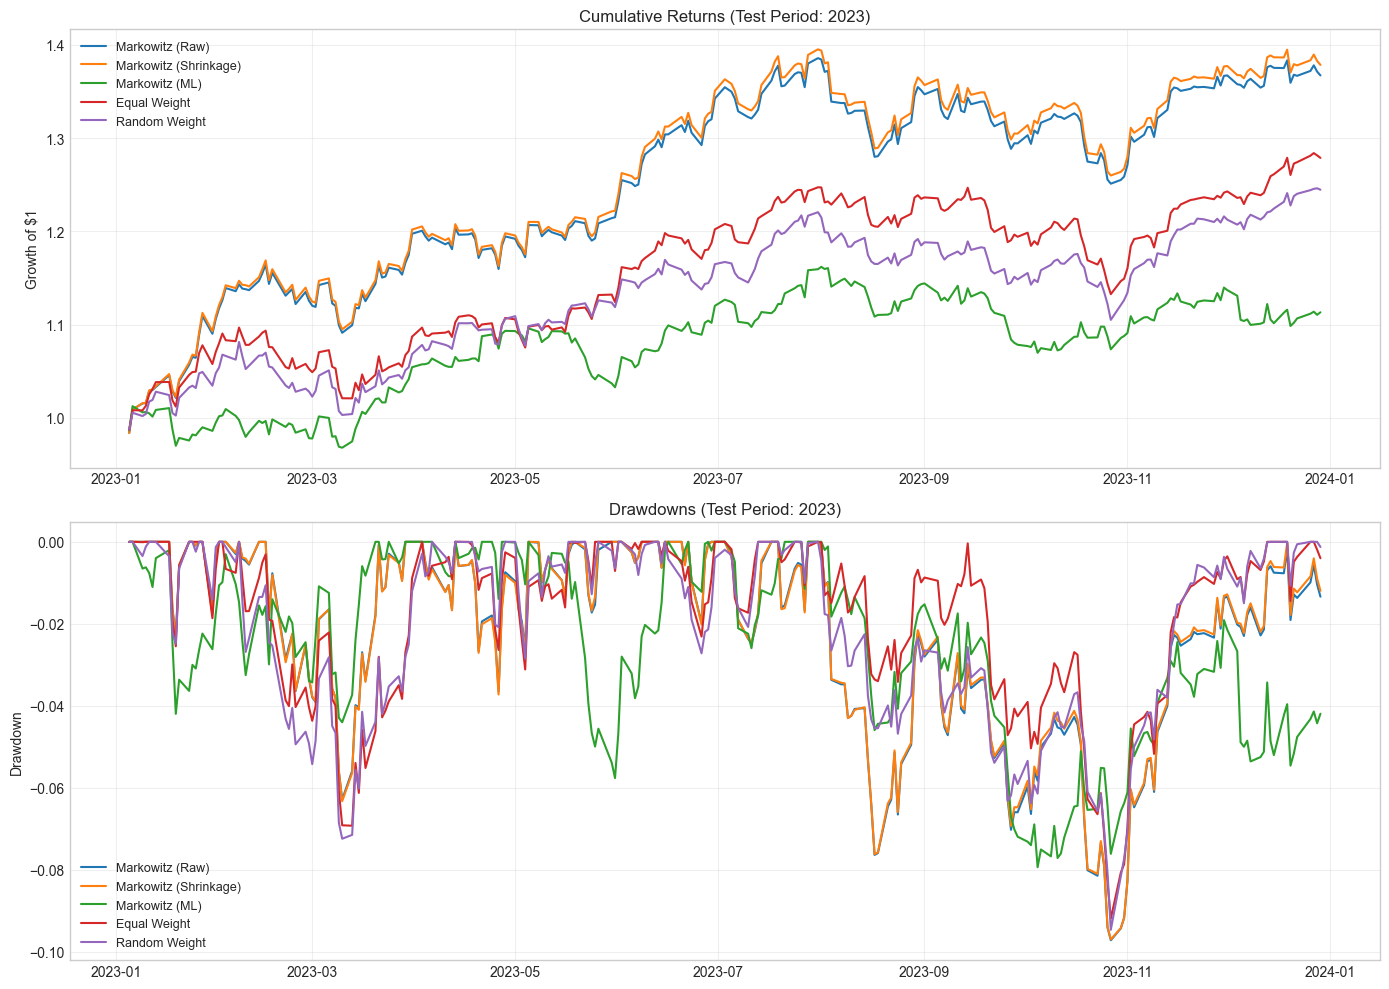

In [14]:
# Cumulative returns comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for name, returns in results.items():
    cum = compute_cumulative_returns(returns)
    axes[0].plot(cum.index, cum.values, label=name, linewidth=1.5)

axes[0].set_title("Cumulative Returns (Test Period: 2023)")
axes[0].set_ylabel("Growth of $1")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Drawdowns
for name, returns in results.items():
    _, dd = compute_max_drawdown(returns)
    axes[1].plot(dd.index, dd.values, label=name, linewidth=1.5)

axes[1].set_title("Drawdowns (Test Period: 2023)")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Efficient Frontier

The efficient frontier shows the set of portfolios that offer the highest return for each level of risk. Portfolios below the frontier are suboptimal — you could get more return for the same risk.

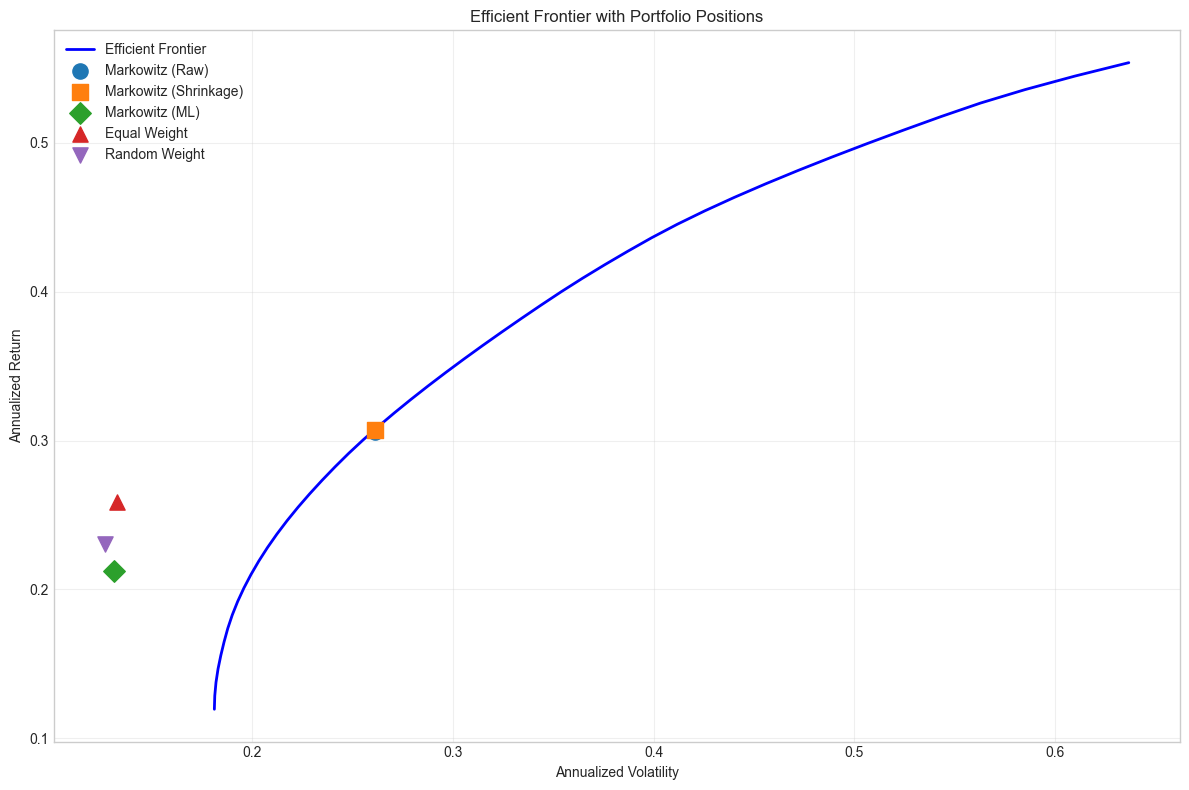

In [15]:
f_vols, f_rets = compute_efficient_frontier(mu, cov_shrink)

plt.figure(figsize=(12, 8))
plt.plot(f_vols, f_rets, 'b-', linewidth=2, label='Efficient Frontier')

# Plot each strategy
markers = ['o', 's', 'D', '^', 'v']
for (name, perf), marker in zip(
    [("Raw", perf_raw), ("Shrinkage", perf_shrink), ("ML", perf_ml)],
    markers
):
    plt.scatter(perf[1], perf[0], s=120, marker=marker, zorder=5,
                label=f"Markowitz ({name})")

# Equal and random weight (use test data performance)
for name, marker in [("Equal Weight", '^'), ("Random Weight", 'v')]:
    ret_s = results[name]
    ann_ret = ret_s.mean() * 252
    ann_vol = ret_s.std() * np.sqrt(252)
    plt.scatter(ann_vol, ann_ret, s=120, marker=marker, zorder=5, label=name)

plt.title("Efficient Frontier with Portfolio Positions")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Rolling Backtest

A single test period (2023) might not be representative. To get more robust results, we perform a **rolling backtest**: train on a 2-year window, test on the next 6 months, then roll forward.

This gives us multiple independent test periods to evaluate consistency.

In [16]:
from src.evaluation import rolling_backtest

all_returns = compute_returns(prices)

def make_strategy(name):
    def fn(prices_w):
        mu_w = compute_expected_returns(prices_w)
        if name == "shrinkage":
            cov_w = compute_covariance_shrinkage(prices_w)
            w, _ = optimize_max_sharpe(mu_w, cov_w)
        elif name == "ml":
            ret_w = compute_returns(prices_w)
            models = train_volatility_model(ret_w)
            cov_w = predict_covariance_ml(models, ret_w, prices_w)
            w, _ = optimize_max_sharpe(mu_w, cov_w)
        elif name == "equal":
            w = equal_weight_portfolio(prices_w.columns.tolist())
        return w
    return fn

rolling = {}
for label, key in [("Shrinkage", "shrinkage"), ("ML", "ml"), ("Equal Weight", "equal")]:
    print(f"Running rolling backtest: {label}")
    rolling[label] = rolling_backtest(prices, all_returns, make_strategy(key))

Running rolling backtest: Shrinkage
  Expected Return: 173.95%
  Volatility:      50.47%
  Sharpe Ratio:    3.45
  Expected Return: 238.24%
  Volatility:      61.06%
  Sharpe Ratio:    3.90
  Expected Return: 177.32%
  Volatility:      49.28%
  Sharpe Ratio:    3.60
  Expected Return: 38.86%
  Volatility:      17.76%
  Sharpe Ratio:    2.19
  Expected Return: 52.49%
  Volatility:      22.10%
  Sharpe Ratio:    2.37
Running rolling backtest: ML


  Trained volatility model for AAPL (R² = 0.971)
  Trained volatility model for AMZN (R² = 0.976)


  Trained volatility model for BAC (R² = 0.973)
  Trained volatility model for CAT (R² = 0.979)


  Trained volatility model for CVX (R² = 0.978)
  Trained volatility model for GOOGL (R² = 0.961)


  Trained volatility model for HON (R² = 0.952)
  Trained volatility model for JNJ (R² = 0.955)


...

  Trained volatility model for NVDA (R² = 0.968)
  Trained volatility model for PFE (R² = 0.965)


  Trained volatility model for PG (R² = 0.966)
  Trained volatility model for TSLA (R² = 0.977)


  Trained volatility model for UNH (R² = 0.951)
  Trained volatility model for V (R² = 0.973)


  Trained volatility model for XOM (R² = 0.938)


  ML-adjusted covariance matrix computed.
  Expected Return: 53.04%
  Volatility:      20.86%
  Sharpe Ratio:    2.54
Running rolling backtest: Equal Weight


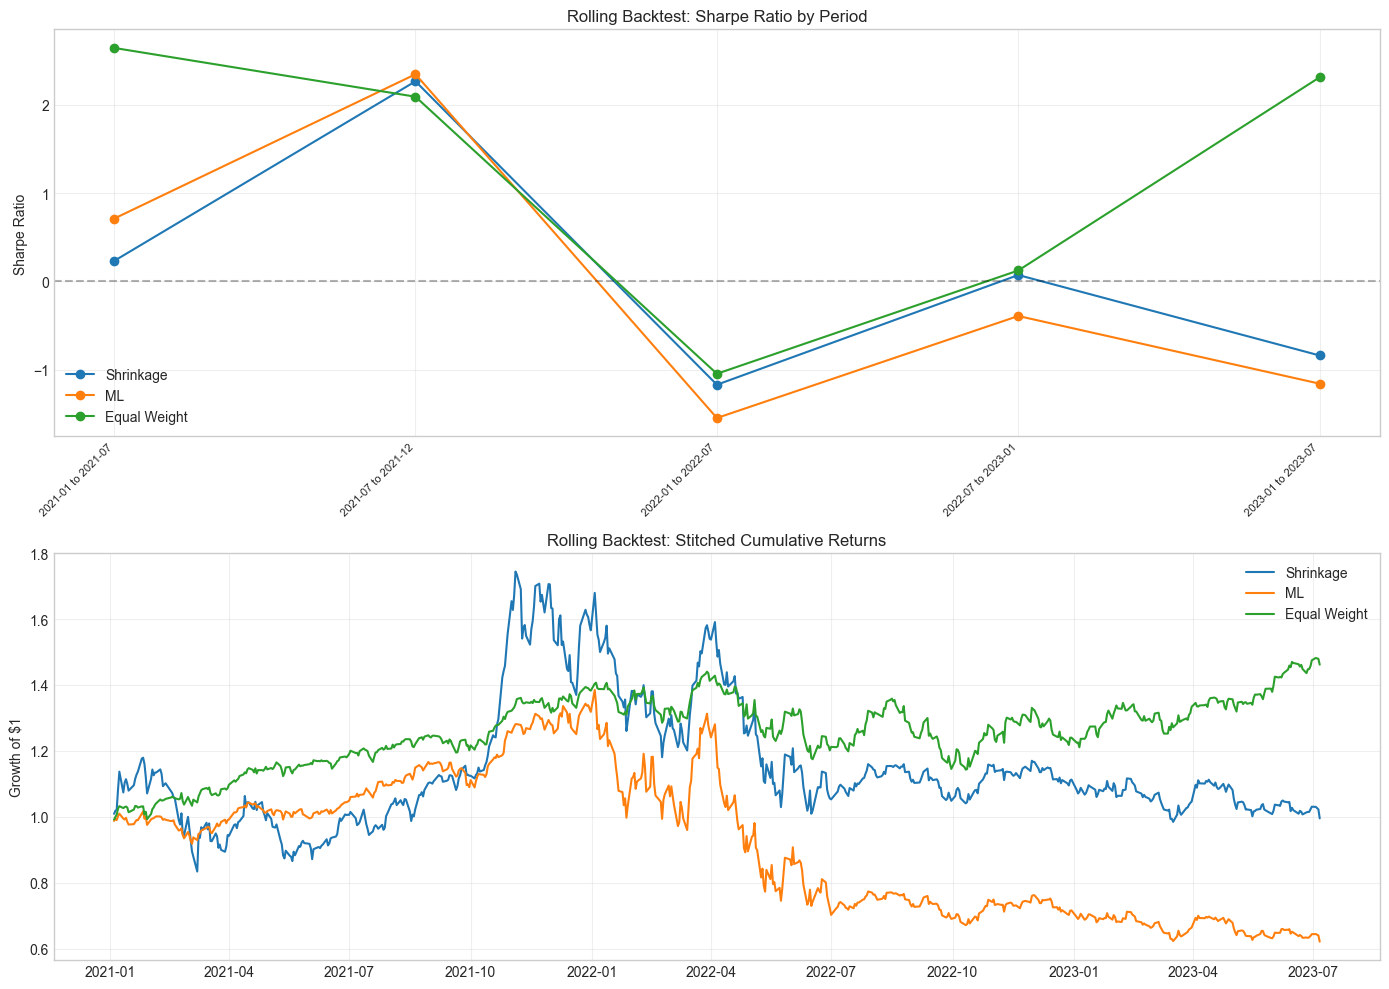


--- Rolling Backtest Summary ---
Shrinkage: Avg Sharpe=0.11, Avg MaxDD=-22.55%, Positive=3/5
ML: Avg Sharpe=-0.01, Avg MaxDD=-18.30%, Positive=2/5
Equal Weight: Avg Sharpe=1.23, Avg MaxDD=-9.87%, Positive=4/5


In [17]:
# Rolling Sharpe comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for name, periods in rolling.items():
    labels = list(periods.keys())
    sharpes = [periods[p]["sharpe"] for p in labels]
    axes[0].plot(range(len(labels)), sharpes, marker='o', label=name)

axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0].set_title("Rolling Backtest: Sharpe Ratio by Period")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].legend()
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)

# Stitched cumulative returns
for name, periods in rolling.items():
    all_r = pd.concat([periods[p]["returns"] for p in periods])
    cum = compute_cumulative_returns(all_r)
    axes[1].plot(cum.index, cum.values, label=name)

axes[1].set_title("Rolling Backtest: Stitched Cumulative Returns")
axes[1].set_ylabel("Growth of $1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n--- Rolling Backtest Summary ---")
for name, periods in rolling.items():
    avg_sharpe = np.mean([p["sharpe"] for p in periods.values()])
    avg_dd = np.mean([p["max_dd"] for p in periods.values()])
    n_pos = sum(1 for p in periods.values() if p["sharpe"] > 0)
    print(f"{name}: Avg Sharpe={avg_sharpe:.2f}, Avg MaxDD={avg_dd:.2%}, Positive={n_pos}/{len(periods)}")

## 8. Analysis & Conclusions

### Why does Equal Weight often beat Markowitz on Sharpe?

This is actually a well-known result in finance called the **"1/N puzzle"** (DeMiguel, Garlappi & Uppal, 2009). Key reasons:

1. **Estimation error**: Markowitz optimization is highly sensitive to errors in expected returns and covariance estimates. Small errors in inputs can lead to wildly different portfolios. Equal weight has zero estimation error — it doesn't try to estimate anything.

2. **Concentration risk**: The optimizer tends to put large bets on a few assets that happened to look good historically. If those stocks don't repeat their performance, the portfolio suffers.

3. **Diversification premium**: Spreading across 18 stocks in 6 sectors captures broad market movements. A sector crash (e.g., tech correction) hurts a concentrated tech-heavy Markowitz portfolio much more than an equal-weight portfolio.

### What does the ML improvement actually do?

The Random Forest volatility model helps by:
- Reducing allocation to stocks predicted to have higher-than-historical volatility
- Creating a more moderate, less concentrated portfolio
- Typically improving Sharpe ratio relative to raw Markowitz (though not always beating equal weight)

### Honest takeaways

- Simple strategies are hard to beat, especially after costs
- ML improves risk estimation, but the improvement is incremental
- The rolling backtest shows this isn't just a one-period fluke
- True value of optimization appears with more assets, longer horizons, and constraints (sector limits, turnover limits)

In [18]:
# Final summary comparison
print("=" * 60)
print("FINAL RESULTS: Single Period (2023)")
print("=" * 60)
print(summary.to_string())

print("\n" + "=" * 60)
print("ROLLING BACKTEST AVERAGES")
print("=" * 60)
for name, periods in rolling.items():
    avg_sharpe = np.mean([p["sharpe"] for p in periods.values()])
    avg_dd = np.mean([p["max_dd"] for p in periods.values()])
    avg_ret = np.mean([p["total_return"] for p in periods.values()])
    print(f"{name:20s} | Avg Return: {avg_ret:7.2%} | Avg Sharpe: {avg_sharpe:5.2f} | Avg Max DD: {avg_dd:7.2%}")

FINAL RESULTS: Single Period (2023)
                      Total Return Ann. Volatility Sharpe Ratio Max Drawdown
Strategy                                                                    
Markowitz (Raw)             36.73%          15.25%         2.03       -9.72%
Markowitz (Shrinkage)       37.86%          15.36%         2.07       -9.70%
Markowitz (ML)              11.32%          13.07%         0.75       -7.94%
Equal Weight                27.88%          13.23%         1.80       -9.19%
Random Weight               24.47%          12.65%         1.66       -9.46%

ROLLING BACKTEST AVERAGES
Shrinkage            | Avg Return:   3.43% | Avg Sharpe:  0.11 | Avg Max DD: -22.55%
ML                   | Avg Return:  -5.86% | Avg Sharpe: -0.01 | Avg Max DD: -18.30%
Equal Weight         | Avg Return:   8.65% | Avg Sharpe:  1.23 | Avg Max DD:  -9.87%
